## Cradit Risk Scoring Project

Credit Risk Scoring is about helping banks decide whether to approve or reject a loan application. When a customer applies for a loan, the bank collects details like income and loan amount, then uses a model to generate a risk score — predicting the likelihood the customer will default.

The model learns from historical loan data, where each record includes the loan details and whether the customer repaid or defaulted. This allows the bank to make faster, data-driven lending decisions.

This problem can be framed as binary classification, where ‘y’ represents the target variable, and it can take on two values: 0 (OK) or 1 (DEFAULT). Our objective is to train a model to predict, for each new customer, the probability that they will default:

g(xi) –> PROBABILITY OF DEFAULT

We have ‘X,’ which encompasses all the customer information, and the target variable ‘y,’ which indicates the default probability.

### Preparation Steps

In [1]:
# import the necessary libraries
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
# download the dataset
data = 'https://github.com/gastonstat/CreditScoring/raw/master/CreditScoring.csv'
!wget $data

--2026-04-18 13:11:02--  https://github.com/gastonstat/CreditScoring/raw/master/CreditScoring.csv
Resolving github.com (github.com)... 20.26.156.215
Connecting to github.com (github.com)|20.26.156.215|:443... connected.
HTTP request sent, awaiting response... 504 Gateway Time-out
Retrying.

--2026-04-18 13:11:14--  (try: 2)  https://github.com/gastonstat/CreditScoring/raw/master/CreditScoring.csv
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 504 Gateway Time-out
Retrying.

--2026-04-18 13:11:17--  (try: 3)  https://github.com/gastonstat/CreditScoring/raw/master/CreditScoring.csv
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 504 Gateway Time-out
Retrying.

--2026-04-18 13:11:20--  (try: 4)  https://github.com/gastonstat/CreditScoring/raw/master/CreditScoring.csv
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 504 Gateway Time-out
Retrying.

--2026-04-18 13:11:24--  (t

In [3]:
# load the dataframe
df = pd.read_csv('CreditScoring.csv')

In [4]:
# Check the first five rows of the dataframe
df.head()

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [5]:
# Adapting column format
# We'll lowercase all the columns for consistency
df.columns = df.columns.str.lower()
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


### Data cleaning and preparation

Here are the key points:

1. Missing Values: The missing values are encoded as a series of nines (99999999). We’ll need to address how to handle these missing values.

2. Categorical Variable Information: The R file also offers information about the categorical variables. For example:
- ‘Status’ is encoded as ‘good’ (1) and ‘bad’ (2).
- ‘Home’ includes categories like ‘rent,’ ‘owner,’ ‘priv,’ ‘ignore,’ ‘parents,’ and ‘other.’
- ‘Marital’ encompasses ‘single,’ ‘married,’ ‘widow,’ ‘separated,’ and ‘divorced.’
- ‘Records’ has ‘yes’ and ‘no.’
- ‘Job’ includes ‘fixed,’ ‘partime,’ ‘freelance,’ and ‘other.’

To proceed, we’ll need to translate these numerical values back into their respective categorical strings. This ensures our data is more interpretable and ready for analysis.

In [6]:
# Re-encoding the categorical variables
# Let's start with the status column
df.status.value_counts()

status
1    3200
2    1254
0       1
Name: count, dtype: int64

In [7]:
status_values = {
    1: 'ok',
    2: 'default',
    0: 'unk'
}

In [8]:
df.status = df.status.map(status_values)
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,1,60,30,2,1,3,73,129,0,0,800,846
1,ok,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,default,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,ok,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,ok,0,1,36,26,1,1,1,46,107,0,0,310,910


In [9]:
# The same re-encoding process applied to the ‘status’ column should also be carried out for the remaining categorical columns: ‘home_values,’ ‘marital_values,’ ‘records_values,’ and ‘job_values’.
df.home.value_counts()

home
2    2107
1     973
5     783
6     319
3     247
4      20
0       6
Name: count, dtype: int64

In [10]:
home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}

In [11]:
df.home = df.home.map(home_values)

In [12]:
# For marital column
df.marital.value_counts()

marital
2    3241
1     978
4     130
3      67
5      38
0       1
Name: count, dtype: int64

In [13]:
marital_values = {
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}

In [14]:
df.marital = df.marital.map(marital_values)

In [15]:
# For records column
df.records.value_counts()

records
1    3682
2     773
Name: count, dtype: int64

In [16]:
records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}

In [17]:
df.records = df.records.map(records_values)

In [18]:
# For job column
df.job.value_counts()

job
1    2806
3    1024
2     452
4     171
0       2
Name: count, dtype: int64

In [19]:
job_values = {
    1: 'fixed',
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unk'
}

In [20]:
df.job = df.job.map(job_values)

In [21]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107,0,0,310,910


In [22]:
# Missing values
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


- It’s apparent that ‘income,’ ‘assets,’ and ‘debt’ columns contain extremely large values (e.g., 99999999.0) as maximum values. To address this issue, we need to replace these outlier values. Let’s explore the replacement process.

In [23]:
df.income.max()

np.int64(99999999)

In [24]:
df.income.replace(to_replace=99999999, value=np.nan)

0       129.0
1       131.0
2       200.0
3       182.0
4       107.0
        ...  
4450     92.0
4451     75.0
4452     90.0
4453    140.0
4454    140.0
Name: income, Length: 4455, dtype: float64

In [25]:
df.income.replace(to_replace=99999999, value=np.nan).max()

np.float64(959.0)

In [26]:
# We'll address the outlier values in a loop for all these columns: 'income', 'assest' and 'debt'.
for c in ['income', 'assets', 'debt']:
    df[c] = df[c].replace(to_replace=99999999, value=np.nan)

In [27]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4421.0,4408.0,4437.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,131.0,5403.0,343.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,86.0,11573.0,1246.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3000.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,165.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,959.0,300000.0,30000.0,5000.0,11140.0


- While analyzing the ‘status’ column, we discovered a single record with the value ‘unk,’ representing a missing or unknown status. Since our focus is solely on ‘ok’ and ‘default’ values, we can safely remove this record from the dataframe.

In [28]:
df.status.value_counts()

status
ok         3200
default    1254
unk           1
Name: count, dtype: int64

In [29]:
# Remove all rows where status is unknown, then renumber the index cleanly
df = df[df.status !='unk'].reset_index(drop=True)
df

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129.0,0.0,0.0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131.0,0.0,0.0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182.0,2500.0,0.0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107.0,0.0,0.0,310,910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4449,default,1,rent,60,39,married,no,fixed,69,92.0,0.0,0.0,900,1020
4450,ok,22,owner,60,46,married,no,fixed,60,75.0,3000.0,600.0,950,1263
4451,default,0,owner,24,37,married,no,partime,60,90.0,3500.0,0.0,500,963
4452,ok,0,rent,48,23,single,no,freelance,49,140.0,0.0,0.0,550,550


In [30]:
# Performing the train, validation and test split
from sklearn.model_selection import train_test_split

In [31]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=11)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=11)

In [32]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [33]:
df_train.status

0       default
1       default
2            ok
3       default
4            ok
         ...   
2667         ok
2668         ok
2669         ok
2670         ok
2671         ok
Name: status, Length: 2672, dtype: str

In [34]:
# Tp predict a probability, we need to convert our target variable 'status' into a numerical format
(df_train.status == 'default').astype('int')

0       1
1       1
2       0
3       1
4       0
       ..
2667    0
2668    0
2669    0
2670    0
2671    0
Name: status, Length: 2672, dtype: int64

In [35]:
# We need to assign target variables for the training, validation and testing sets
y_train = (df_train.status == 'default').astype('int').values
y_val = (df_val.status == 'default').astype('int').values
y_test = (df_test.status == 'default').astype('int').values

In [36]:
# We'll remove the target variables from 'df_train', 'df_val' and 'df_test', to prevent accidental use of the target variable during training
del df_train['status']
del df_val['status']
del df_test['status']

In [37]:
df_train

,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,10,owner,36,36,married,no,freelance,75,0.0,10000.0,0.0,1000,1400
1,6,parents,48,32,single,yes,fixed,35,85.0,0.0,0.0,1100,1330
2,1,parents,48,40,married,no,fixed,75,121.0,0.0,0.0,1320,1600
3,1,parents,48,23,single,no,partime,35,72.0,0.0,0.0,1078,1079
4,5,owner,36,46,married,no,freelance,60,100.0,4000.0,0.0,1100,1897
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2667,18,private,36,45,married,no,fixed,45,220.0,20000.0,0.0,800,1600
2668,7,private,60,29,married,no,fixed,60,51.0,3500.0,500.0,1000,1290
2669,1,parents,24,19,single,no,fixed,35,28.0,0.0,0.0,400,600
2670,15,owner,48,43,married,no,freelance,60,100.0,18000.0,0.0,2500,2976


### Training a decision tree

In [38]:
# Import the necessary libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score

In [39]:
# We need to turn our training dataframe into a list of dictionaries then turn this list of dictionaries into the feature matrix. After that we train the model.
train_dicts = df_train.fillna(0).to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)
X_train

array([[3.60e+01, 1.00e+03, 1.00e+04, ..., 0.00e+00, 1.00e+01, 3.60e+01],
       [3.20e+01, 1.10e+03, 0.00e+00, ..., 1.00e+00, 6.00e+00, 4.80e+01],
       [4.00e+01, 1.32e+03, 0.00e+00, ..., 0.00e+00, 1.00e+00, 4.80e+01],
       ...,
       [1.90e+01, 4.00e+02, 0.00e+00, ..., 0.00e+00, 1.00e+00, 2.40e+01],
       [4.30e+01, 2.50e+03, 1.80e+04, ..., 0.00e+00, 1.50e+01, 4.80e+01],
       [2.70e+01, 4.50e+02, 5.00e+03, ..., 1.00e+00, 1.20e+01, 4.80e+01]],
      shape=(2672, 29))

In [40]:
# Let's train our model
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [41]:
# Let's look at the performance of our trained Decision Tree
val_dicts = df_val.fillna(0).to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [42]:
y_pred = dt.predict_proba(X_val)[:, 1]

In [43]:
roc_auc_score(y_val, y_pred)

0.6510377564118088

In [44]:
### Overfitting
# 0.65 is not really a great value, let’s look at training data and calulate auc score
y_pred = dt.predict_proba(X_train)[:, 1]
roc_auc_score(y_train, y_pred)

1.0

- This is called overfitting. If we restrict the tree to only grow up to three levels deep, the tree will learn rules that are less specific.

In [45]:
dt = DecisionTreeClassifier(max_depth=3)

In [46]:
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [47]:
y_pred = dt.predict_proba(X_train)[:, 1]
auc = roc_auc_score(y_train, y_pred)
print('train', auc)

train 0.7761016984958594


In [48]:
y_pred = dt.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
print('val', auc)

val 0.7389079944782155


- If we restrict the depth to 3, the model performance on validation is significantly better. It’s now 74% compared to 65%.

In [49]:
# Decision stump


- A decistion tree with a depth of 1 is called Decision Stump. It’s not really a tree, because this is only one condition.

In [50]:
dt = DecisionTreeClassifier(max_depth=1)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [51]:
y_pred = dt.predict_proba(X_train)[:, 1]
auc = roc_auc_score(y_train, y_pred)
print('train', auc)

train 0.6282660131823559


In [52]:
y_pred = dt.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
print('val', auc)

val 0.6058644740984719


- The auc score of this decision stump is only a bit worse than the overfitted one.

In [53]:
# Visualizing decision stump
from sklearn.tree import export_text

In [54]:
print(export_text(dt))

|--- feature_25 <= 0.50
|   |--- class: 1
|--- feature_25 >  0.50
|   |--- class: 0



- To understand the meaning of 'feature_26', we need to consult the DictVectorizer feature names dictionary.

In [55]:
names = dv.get_feature_names_out().tolist()
print(export_text(dt, feature_names=names))

|--- records=no <= 0.50
|   |--- class: 1
|--- records=no >  0.50
|   |--- class: 0



- This means that if there are no records (records=no <= 0.50), it’s labeled as ‘DEFAULT.’ If there are records (records=no > 0.50), it’s labeled as ‘OK.’ It’s important to note that one-hot encoding is applied here, and there is a column named ‘records=NO,’ which is encoded as 0 when it’s not ‘no’ and 1 when it’s ‘no’.

In [56]:
# Decision tree with depth of 2
dt = DecisionTreeClassifier(max_depth=2)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [57]:
y_pred = dt.predict_proba(X_train)[:, 1]
auc = roc_auc_score(y_train, y_pred)
print('train', auc)

train 0.7054989859726213


In [58]:
y_pred = dt.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
print('val', auc)

val 0.6685264343319367


In [59]:
# Visualizing decision tree
print(export_text(dt))

|--- feature_25 <= 0.50
|   |--- feature_27 <= 6.50
|   |   |--- class: 1
|   |--- feature_27 >  6.50
|   |   |--- class: 0
|--- feature_25 >  0.50
|   |--- feature_16 <= 0.50
|   |   |--- class: 0
|   |--- feature_16 >  0.50
|   |   |--- class: 1



In [60]:
names = dv.get_feature_names_out().tolist()
print(export_text(dt, feature_names=names))

|--- records=no <= 0.50
|   |--- seniority <= 6.50
|   |   |--- class: 1
|   |--- seniority >  6.50
|   |   |--- class: 0
|--- records=no >  0.50
|   |--- job=partime <= 0.50
|   |   |--- class: 0
|   |--- job=partime >  0.50
|   |   |--- class: 1



### Decision trees parameter tuning

-> Parameter tuning involves selecting the best parameters for training. In this context, ‘tuning’ means choosing parameters in a way that maximizes or minimizes a chosen performance metric (such as AUC or RMSE) on the validation set. In the case of AUC, our goal is to maximize it on the validation set by finding the parameter values that yield the highest score.

-> Let’s take a closer look at the parameters available for the DecisionTreeClassifier. Some of the key parameters include:
1. criterion: This parameter determines the impurity measure used for splitting. You can choose between ‘gini’ for Gini impurity and ‘entropy’ for information gain. The choice of criterion can significantly impact the quality of the splits in the decision tree.
2. max_depth: This parameter controls the maximum depth of the decision tree. It plays a crucial role in preventing overfitting by limiting the complexity of the tree. Selecting an appropriate value for max_depth helps strike a balance between model simplicity and complexity.
3. min_samples_leaf: This parameter specifies the minimum number of samples required in a leaf node. It influences the granularity of the splits. Smaller values can result in finer splits and a more complex tree, while larger values lead to coarser splits and a simpler tree.

In [61]:
# Selecting max_depth
depths = [1, 2, 3, 4, 5, 6, 10, 15, 20, None]

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth)
    dt.fit(X_train, y_train)

    # Remember we used the column with negative scores
    y_pred = dt.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)

    print('%4s -> %.3f' % (depth, auc))

   1 -> 0.606
   2 -> 0.669
   3 -> 0.739
   4 -> 0.761
   5 -> 0.767
   6 -> 0.756
  10 -> 0.696
  15 -> 0.665
  20 -> 0.634
None -> 0.668


- What we can observe here is that the optimal values appear to be around 76% for ‘max_depth’ values of 4 and 5. This indicates that our best-performing tree should have between 4 to 5 layers. If there were no other parameters to consider, we could choose a depth of 4 to make the tree simpler, with only 4 layers instead of 5. A simpler tree is generally easier to read and understand, making it more transparent in terms of what’s happening.

In [62]:
# Selecting min_samples_leaf

-> But ‘max_depth‘ is not the only parameter; there is another one called ‘min_samples_leaf.’ We have already determined that the optimal depth falls between 4 and 6. For each of these values, we can experiment with different ‘min_samples_leaf‘ values to observe their effects.

In [63]:
scores = []

for d in [4, 5]:
    for s in [1, 2, 5, 10, 15, 20, 100, 200, 500]:
        dt = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=s)
        dt.fit(X_train, y_train)

        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((d, s, auc))

columns = ['max_depth', 'min_samples_leaf', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores.head()

,max_depth,min_samples_leaf,auc
0,4,1,0.642946
1,4,2,0.685104
2,4,5,0.715649
3,4,10,0.758631
4,4,15,0.786921


In [64]:
df_scores.sort_values(by='auc', ascending=False).head()

,max_depth,min_samples_leaf,auc
13,5,15,0.787563
4,4,15,0.786921
14,5,20,0.785501
5,4,20,0.780558
15,5,100,0.779725


-> This information can be presented differently by transforming it into a DataFrame. In this DataFrame, ‘min_samples_leaf‘ will be on the rows, ‘max_depth‘ will be on the columns, and the cell values will represent the ‘auc‘ scores. To achieve this, we can utilize the ‘pivot’ function. This tabular format is more user-friendly, and it’s evident that 0.787 is the highest value.

In [65]:
# Index - row
df_scores_pivot = df_scores.pivot(index='min_samples_leaf', columns=['max_depth'], values=['auc'])
df_scores_pivot.round(3)

auc       
max_depth             4      5
min_samples_leaf              
1                 0.643  0.649
2                 0.685  0.697
5                 0.716  0.709
10                0.759  0.763
15                0.787  0.788
20                0.781  0.786
100               0.779  0.780
200               0.768  0.768
500               0.680  0.680

In [66]:
# Let's explore a few more combinations
scores = []

for d in [4, 5, 6, 7, 10, 15, 20, None]:
    for s in [1, 2, 5, 10, 15, 20, 100, 200, 500]:
        dt = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=s)
        dt.fit(X_train, y_train)

        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((d, s, auc))

columns = ['max_depth', 'min_samples_leaf', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

df_scores.sort_values(by='auc', ascending=False).head()

,max_depth,min_samples_leaf,auc
58,20.0,15,0.787947
31,7.0,15,0.787887
4,4.0,15,0.787490
13,5.0,15,0.787448
67,NaN,15,0.787290


In [67]:
# Index-rows
df_scores_pivot = df_scores.pivot(index='min_samples_leaf', columns=['max_depth'], values=['auc'])
df_scores_pivot.round(3)

auc                                                 
max_depth           NaN   4.0    5.0    6.0    7.0    10.0   15.0   20.0
min_samples_leaf                                                        
1                 0.650  0.659  0.662  0.672  0.657  0.653  0.644  0.654
2                 0.695  0.692  0.685  0.690  0.695  0.677  0.700  0.693
5                 0.718  0.720  0.716  0.713  0.717  0.720  0.714  0.720
10                0.763  0.756  0.763  0.764  0.760  0.760  0.762  0.761
15                0.787  0.787  0.787  0.786  0.788  0.787  0.787  0.788
20                0.783  0.786  0.782  0.781  0.784  0.780  0.785  0.783
100               0.779  0.780  0.779  0.780  0.779  0.780  0.779  0.780
200               0.768  0.768  0.768  0.768  0.768  0.768  0.768  0.768
500               0.680  0.680  0.680  0.680  0.680  0.680  0.680  0.680

-> We'll train our DecisionTreeClassifier with the final tuned parameters: ‘max_depth‘ set to 7 and ‘min_samples_leaf‘ set to 15

In [68]:
dt = DecisionTreeClassifier(max_depth=7, min_samples_leaf=15)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [69]:
y_pred = dt.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)

print('val', auc)

val 0.7796250999007047


### Ensemble learning and Random Forest

-> Ensemble models ( Board of experts concept): This method of aggregating multiple models is applicable to any type of model. However, in this case, we specifically focus on using decision trees. When we ensemble decision trees, we create what is known as a ‘random forest.’

In [70]:
from sklearn.ensemble import RandomForestClassifier

In [71]:
# n_estimators - number of models we want to use
rf = RandomForestClassifier(n_estimators=10)
rf.fit(X_train, y_train) 

y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.7943498583226368

In [72]:
# Credit risk probability for a single customer
rf.predict_proba(X_val[[0]])

array([[0.8, 0.2]])

-> To ensure consistent and reproducible results, we can use the ‘random_state’ parameter. By setting a fixed ‘random_state,’ regardless of how many times we run the model, the results will remain the same.

In [73]:
rf = RandomForestClassifier(n_estimators=10, random_state=1)
rf.fit(X_train, y_train)

y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.7744726453706618

In [74]:
# Credit risk probability for a single customer
rf.predict_proba(X_val[[0]])

array([[0.9, 0.1]])

- 90% confident this customer is a good credit risk

### Tuning random forest

-> To start, we’ll explore how the model’s performance evolves when we increase the number of estimators or models it employs. Our approach will involve iterating over a range of values to observe how the model’s performance improves or changes with an increasing number of trees.

In [75]:
scores = []

for n in range (10, 201, 10):
    rf = RandomForestClassifier(n_estimators=n, random_state=1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)

    scores.append((n, auc))

df_scores = pd.DataFrame(scores, columns=['n_estimators', 'auc'])
df_scores

,n_estimators,auc
0,10,0.774473
1,20,0.803532
2,30,0.815075
3,40,0.815686
4,50,0.817082
5,60,0.816458
6,70,0.817321
7,80,0.816307
8,90,0.816824
9,100,0.817599


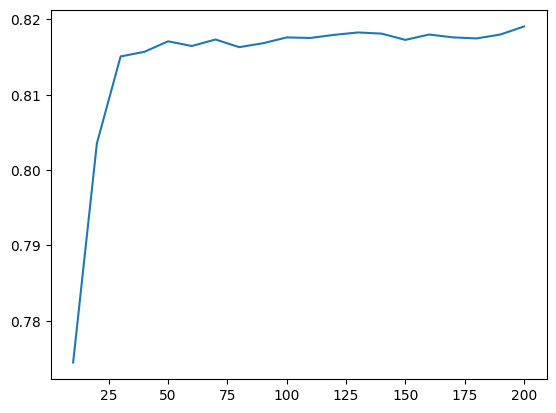

In [76]:
# x-axis - n_estimators
# y-axis - auc score
plt.plot(df_scores.n_estimators, df_scores.auc)

-> We observe that the model’s performance improves as we increase the number of estimators up to 50, but beyond that point, it reaches a plateau. Additional trees don’t significantly enhance the performance. Hence, training more than 50 trees doesn’t appear to be beneficial.

-> Now, let’s proceed with tuning our random forest model. It’s important to note that a random forest comprises multiple decision trees, so the parameters we tune within the random forest are essentially the same—specifically, we are interested in the max_depth and min_samples_leaf parameters. Starting with the max_dept‘ parameter, we aim to train a random forest model with different depth values to assess its impact on performance.

In [77]:
scores = []

for d in [5, 10, 15]:
    for n in range (10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=d,
                                    random_state=1)
        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((d, n, auc))

columns = ['max_depth', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores

,max_depth,n_estimators,auc
0,5,10,0.787699
1,5,20,0.797731
2,5,30,0.800305
3,5,40,0.799708
4,5,50,0.799878
5,5,60,0.801167
6,5,70,0.802251
7,5,80,0.803244
8,5,90,0.803616
9,5,100,0.804452


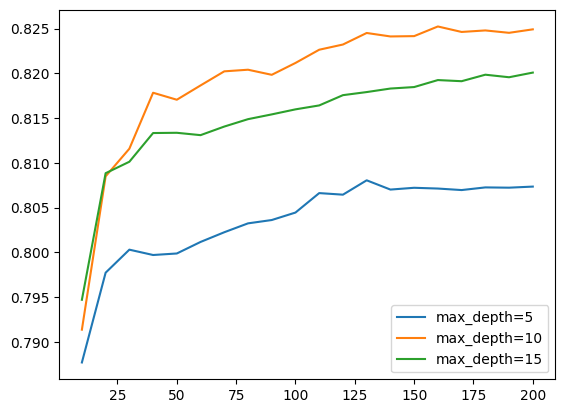

In [78]:
# Let's plot it 
for d in [5, 10, 15]:
    df_subset = df_scores[df_scores.max_depth == d ]

    plt.plot(df_subset.n_estimators, df_subset.auc, label='max_depth=%d' % d)

plt.legend()

-> In the plot, we can observe that the AUC scores for ‘max_depth’ values of 10 and 15 are initially quite close, but after a certain point, the score for ‘max_depth‘ 15 begins to level off, showing only marginal improvement. In contrast, ‘max_depth‘ 10 continues to perform significantly better, peaking at around 125. This clearly illustrates that the choice of ‘max_depth‘ indeed matters. We can confidently select a value of 10 as the best choice, as the difference between 10 and 15, and between 10 and 5, is notably significant.

In [79]:
# Let's select 10 as the best value
max_depth = 10

In [80]:
# Now, we’ll proceed to find the optimal value for the ‘min_samples_leaf’ parameter using a similar method as before

scores = []

for s in [1, 3, 5, 10, 50]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=max_depth,
                                    min_samples_leaf=s,
                                    random_state=1)
        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((s, n, auc))

columns = ['min_samples_leaf', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

In [81]:
# For a better distinction between the graphs in the following plot, we can change the colors
colors = ['black', 'blue', 'orange', 'red', 'grey']
min_samples_leaf_values = [1, 3, 5, 10, 50]
list(zip(min_samples_leaf_values, colors))

[(1, 'black'), (3, 'blue'), (5, 'orange'), (10, 'red'), (50, 'grey')]

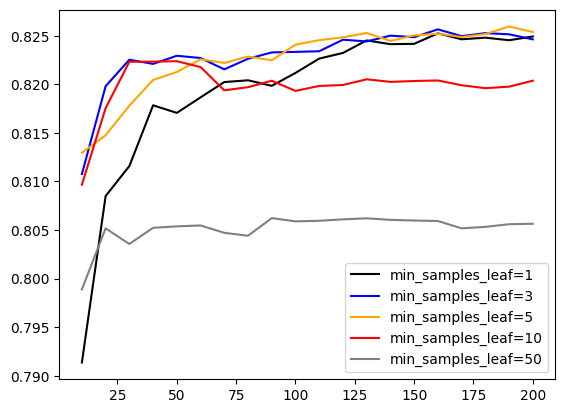

In [82]:
colors = ['black', 'blue', 'orange', 'red', 'grey']
min_samples_leaf_values = [1, 3, 5, 10, 50]

for s, col in zip(min_samples_leaf_values, colors):
    df_subset = df_scores[df_scores.min_samples_leaf == s]

    plt.plot(df_subset.n_estimators, df_subset.auc, color=col, label='min_samples_leaf=%d' % s)

plt.legend()

- We can observe that ‘min_samples_leaf’ set to 50 performs the worst, while the three most favorable options are 1, 3, and 5. Among these, ‘min_samples_leaf’ of 3 stands out a good choice since it achieves good performance earlier than the others.

In [83]:
# Let's select 3 as the best value
min_samples_leaf = 3

In [84]:
# Now, we're ready to retrain the model using these selected values
rf = RandomForestClassifier(n_estimators=100,
                            max_depth=max_depth,
                            min_samples_leaf=min_samples_leaf,
                            random_state=1,
                            n_jobs=-1)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### Gradient boosting and XGBoost

This time, we delve into a different approach for combining decision trees, where models are trained sequentially, with each new model correcting the errors of the previous one. This method of model combination is known as boosting. 

In [85]:
# Import the necessary library
import xgboost as xgb

-> The first step in the process is to structure the training data into a specialized data format known as ‘DMatrix.’ This format is optimized for training XGBoost models, allowing for faster training.

In [86]:
# Define parameters
xgb_params = {
    'eta' : 0.3,
    'max_depth' : 6,
    'min_child_weight' : 1,

    'objective' : 'binary:logistic',
    'nthread' : 8,

    'seed' : 1,
    'verbosity' : 1,
}

In [87]:
# Convert to DMatrix
dtrain = xgb.DMatrix(X_train, y_train)
dval = xgb.DMatrix(X_val, y_val)

In [88]:
# Train
model = xgb.train(xgb_params, dtrain, num_boost_round = 10)

In [89]:
# Let's test the model, with predict function of the XGBoost model
y_pred = model.predict(dval)

In [90]:
# We'll proceed to calculate the AUC
roc_auc_score(y_val, y_pred)

0.8118506454190986

In [91]:
# Performance monitoring
watchlist = [(dtrain, 'train'), (dval, 'val')]

-> By default, XGBoost displays the error rate (logloss), a metric commonly used for parameter tuning. However, given the technical nature of this metric, we’ll opt for another more accessible metric for our analysis.

In [92]:
xgb_params = {
    'eta' : 0.3,
    'max_depth' : 6,
    'min_child_weight' : 1,

    'objective' : 'binary:logistic',

    'nthread' : 8,
    'seed' : 1,
    'verbosity' : 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round = 200, evals = watchlist)

[0]	train-logloss:0.49519	val-logloss:0.54162
[1]	train-logloss:0.44292	val-logloss:0.51347
[2]	train-logloss:0.40693	val-logloss:0.50000
[3]	train-logloss:0.37750	val-logloss:0.48710
[4]	train-logloss:0.35592	val-logloss:0.48213
[5]	train-logloss:0.34003	val-logloss:0.47738
[6]	train-logloss:0.32514	val-logloss:0.47511
[7]	train-logloss:0.31529	val-logloss:0.47448
[8]	train-logloss:0.30160	val-logloss:0.47208
[9]	train-logloss:0.29310	val-logloss:0.47334
[10]	train-logloss:0.28264	val-logloss:0.47539
[11]	train-logloss:0.27676	val-logloss:0.47689
[12]	train-logloss:0.26889	val-logloss:0.47448
[13]	train-logloss:0.26191	val-logloss:0.47187
[14]	train-logloss:0.25553	val-logloss:0.47187
[15]	train-logloss:0.24793	val-logloss:0.47265
[16]	train-logloss:0.24216	val-logloss:0.47464
[17]	train-logloss:0.23724	val-logloss:0.47405
[18]	train-logloss:0.23218	val-logloss:0.47529
[19]	train-logloss:0.22824	val-logloss:0.47574
[20]	train-logloss:0.22328	val-logloss:0.47866
[21]	train-logloss:0.21

-> For our monitoring purposes, we choose to use AUC as the metric, which we’ve previously employed. To do this, we set the eval_metric parameter to auc.

In [93]:
xgb_params = {
    'eta' : 0.3,
    'max_depth': 6, 
    'min_child_weight' : 1,

    'objective' : 'binary:logistic',
    'eval_metric' : 'auc',

    'nthread' : 8,
    'seed': 1,
    'verbosity' : 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round = 200, evals = watchlist)

[0]	train-auc:0.86653	val-auc:0.77999
[1]	train-auc:0.89089	val-auc:0.79060
[2]	train-auc:0.90503	val-auc:0.78881
[3]	train-auc:0.91573	val-auc:0.79997
[4]	train-auc:0.92429	val-auc:0.80367
[5]	train-auc:0.92969	val-auc:0.80822
[6]	train-auc:0.93630	val-auc:0.81043
[7]	train-auc:0.94073	val-auc:0.81173
[8]	train-auc:0.94748	val-auc:0.81328
[9]	train-auc:0.95012	val-auc:0.81185
[10]	train-auc:0.95512	val-auc:0.81115
[11]	train-auc:0.95661	val-auc:0.81133
[12]	train-auc:0.95936	val-auc:0.81433
[13]	train-auc:0.96146	val-auc:0.81863
[14]	train-auc:0.96427	val-auc:0.81872
[15]	train-auc:0.96767	val-auc:0.81993
[16]	train-auc:0.96975	val-auc:0.81863
[17]	train-auc:0.97158	val-auc:0.82002
[18]	train-auc:0.97336	val-auc:0.82015
[19]	train-auc:0.97499	val-auc:0.81979
[20]	train-auc:0.97648	val-auc:0.81877
[21]	train-auc:0.97773	val-auc:0.81969
[22]	train-auc:0.97842	val-auc:0.81880
[23]	train-auc:0.97902	val-auc:0.81805
[24]	train-auc:0.98102	val-auc:0.81686
[25]	train-auc:0.98248	val-auc:0.81

-> The AUC on the training data reaches perfect accuracy (equal to one), but on the validation data, the performance remains relatively stable at around 80%. This suggests that the model may be overfitting.

To make this output more user-friendly, it would be beneficial to visualize it. Instead of printing output for every epoch, we can use verbose_eval=5 to display results only for every 5th epoch, making the monitoring process more manageable.

In [94]:
xgb_params = {
    'eta' : 0.3,
    'max_depth' : 6,
    'min_child_weight' : 1,

    'objective' : 'binary:logistic',
    'eval_metric' : 'auc',

    'nthread' : 8,
    'seed' : 1,
    'verbosity' : 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round = 200, verbose_eval = 5, evals = watchlist)

[0]	train-auc:0.86653	val-auc:0.77999
[5]	train-auc:0.92969	val-auc:0.80822
[10]	train-auc:0.95512	val-auc:0.81115
[15]	train-auc:0.96767	val-auc:0.81993
[20]	train-auc:0.97648	val-auc:0.81877
[25]	train-auc:0.98248	val-auc:0.81520
[30]	train-auc:0.98844	val-auc:0.81613
[35]	train-auc:0.99244	val-auc:0.81453
[40]	train-auc:0.99393	val-auc:0.81407
[45]	train-auc:0.99568	val-auc:0.81392
[50]	train-auc:0.99723	val-auc:0.81276
[55]	train-auc:0.99804	val-auc:0.81299
[60]	train-auc:0.99861	val-auc:0.81244
[65]	train-auc:0.99916	val-auc:0.81197
[70]	train-auc:0.99962	val-auc:0.81243
[75]	train-auc:0.99975	val-auc:0.81152
[80]	train-auc:0.99989	val-auc:0.81359
[85]	train-auc:0.99993	val-auc:0.81193
[90]	train-auc:0.99998	val-auc:0.81038
[95]	train-auc:0.99999	val-auc:0.80871
[100]	train-auc:0.99999	val-auc:0.80842
[105]	train-auc:1.00000	val-auc:0.80778
[110]	train-auc:1.00000	val-auc:0.80764
[115]	train-auc:1.00000	val-auc:0.80722
[120]	train-auc:1.00000	val-auc:0.80750
[125]	train-auc:1.0000

### Parsing xgboost's monitoring output

-> When you’re interested in visualizing this information on a plot, one of the challenges with XGBoost is that it doesn’t provide an easy way to extract this information since it’s printed to standard output. However, in Jupyter Notebook, there’s a method to capture whatever is printed to standard output and manipulate it. You can use the command %%capture output to achieve this. It captures all the content that the code outputs into a special object, which you can then use to extract the information. It’s worth noting that although something is happening in the code, we won’t see any output because it’s being captured.

In [95]:
%%capture output

xgb_params = {
    'eta' : 0.3,
    'max_depth' : 6,
    'min_child_weight' : 1,

    'objective' : 'binary:logistic',
    'eval_metric' : 'auc',

    'nthread' : 8,
    'seed' : 1,
    'verbosity' : 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round = 200, verbose_eval = 5, evals = watchlist)

In [96]:
s = output.stdout
print(s)

[0]	train-auc:0.86653	val-auc:0.77999
[5]	train-auc:0.92969	val-auc:0.80822
[10]	train-auc:0.95512	val-auc:0.81115
[15]	train-auc:0.96767	val-auc:0.81993
[20]	train-auc:0.97648	val-auc:0.81877
[25]	train-auc:0.98248	val-auc:0.81520
[30]	train-auc:0.98844	val-auc:0.81613
[35]	train-auc:0.99244	val-auc:0.81453
[40]	train-auc:0.99393	val-auc:0.81407
[45]	train-auc:0.99568	val-auc:0.81392
[50]	train-auc:0.99723	val-auc:0.81276
[55]	train-auc:0.99804	val-auc:0.81299
[60]	train-auc:0.99861	val-auc:0.81244
[65]	train-auc:0.99916	val-auc:0.81197
[70]	train-auc:0.99962	val-auc:0.81243
[75]	train-auc:0.99975	val-auc:0.81152
[80]	train-auc:0.99989	val-auc:0.81359
[85]	train-auc:0.99993	val-auc:0.81193
[90]	train-auc:0.99998	val-auc:0.81038
[95]	train-auc:0.99999	val-auc:0.80871
[100]	train-auc:0.99999	val-auc:0.80842
[105]	train-auc:1.00000	val-auc:0.80778
[110]	train-auc:1.00000	val-auc:0.80764
[115]	train-auc:1.00000	val-auc:0.80722
[120]	train-auc:1.00000	val-auc:0.80750
[125]	train-auc:1.0000

-> Now that we have the captured output in a string, the first step is to split it into individual lines by using the new line operator \n. The result is a string for each line of the output.

In [97]:
s.split('\n')

['[0]\ttrain-auc:0.86653\tval-auc:0.77999',
 '[5]\ttrain-auc:0.92969\tval-auc:0.80822',
 '[10]\ttrain-auc:0.95512\tval-auc:0.81115',
 '[15]\ttrain-auc:0.96767\tval-auc:0.81993',
 '[20]\ttrain-auc:0.97648\tval-auc:0.81877',
 '[25]\ttrain-auc:0.98248\tval-auc:0.81520',
 '[30]\ttrain-auc:0.98844\tval-auc:0.81613',
 '[35]\ttrain-auc:0.99244\tval-auc:0.81453',
 '[40]\ttrain-auc:0.99393\tval-auc:0.81407',
 '[45]\ttrain-auc:0.99568\tval-auc:0.81392',
 '[50]\ttrain-auc:0.99723\tval-auc:0.81276',
 '[55]\ttrain-auc:0.99804\tval-auc:0.81299',
 '[60]\ttrain-auc:0.99861\tval-auc:0.81244',
 '[65]\ttrain-auc:0.99916\tval-auc:0.81197',
 '[70]\ttrain-auc:0.99962\tval-auc:0.81243',
 '[75]\ttrain-auc:0.99975\tval-auc:0.81152',
 '[80]\ttrain-auc:0.99989\tval-auc:0.81359',
 '[85]\ttrain-auc:0.99993\tval-auc:0.81193',
 '[90]\ttrain-auc:0.99998\tval-auc:0.81038',
 '[95]\ttrain-auc:0.99999\tval-auc:0.80871',
 '[100]\ttrain-auc:0.99999\tval-auc:0.80842',
 '[105]\ttrain-auc:1.00000\tval-auc:0.80778',
 '[110]\tt

-> Each line consists of three components: the number of iterations, the evaluation on the training dataset, and the evaluation on the validation dataset. We can split these components using the tabulator operator \t, resulting in three separate components. To ensure the correct format (integer, float, float), we utilize the strip method and perform the necessary string-to-integer and string-to-float conversions. The following snippet demonstrates these steps.

In [98]:
# 's' is that full output string
# .split('\n') breaks it into a list by line
# [0] grabs the first line only
line = s.split('\n')[0]
line

'[0]\ttrain-auc:0.86653\tval-auc:0.77999'

In [99]:
# split by tab
line.split('\t')

['[0]', 'train-auc:0.86653', 'val-auc:0.77999']

In [100]:
# This line splits and unpacks in one go
num_iter, train_auc, val_auc = line.split('\t')

# Then this just displays all three values
num_iter, train_auc, val_auc

('[0]', 'train-auc:0.86653', 'val-auc:0.77999')

In [101]:
# Clean up num_iter
int(num_iter.strip('[]'))

0

In [102]:
# Clean up scores
float(train_auc.split(':')[1])

0.86653

In [103]:
float(val_auc.split(':')[1])

0.77999

->  We can combine all these steps to transform the information (number of iterations, AUC on the training data, and AUC on the validation data) from the output into a dataframe. The following snippet encapsulates all these steps within a single function for ease of use. This allows us to plot the data and perform further analysis.

In [104]:
# Let's parse the raw text output from XGBoost training and converts it into a clean, readable Pandas DataFrame

def parse_xgb_output(output):
    results = []

    for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')
        
        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])
        
        results.append((it, train, val))
    columns = ['num_iter', 'train_auc', 'val_auc']
    df_results = pd.DataFrame(results, columns=columns)
    return df_results

In [105]:
# Now, let's see how the function works in action
df_score = parse_xgb_output(output)
df_score

,num_iter,train_auc,val_auc
0,0,0.86653,0.77999
1,5,0.92969,0.80822
2,10,0.95512,0.81115
3,15,0.96767,0.81993
4,20,0.97648,0.81877
5,25,0.98248,0.81520
6,30,0.98844,0.81613
7,35,0.99244,0.81453
8,40,0.99393,0.81407
9,45,0.99568,0.81392


- The result of the parse_xgb_output function is a dataframe, enabling us to utilize the plot function for graph visualization

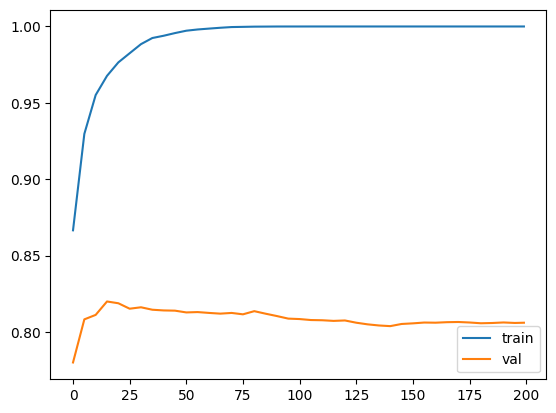

In [106]:
# x-axis - number of iterations
# y_axis - auc
plt.plot(df_score.num_iter, df_score.train_auc, label = 'train')
plt.plot(df_score.num_iter, df_score.val_auc, label = 'val')
plt.legend()

-> We can observe that the AUC on the training dataset consistently improves. However, the picture is different for the validation dataset. The curve reaches its peak earlier and then starts to decline and stagnate, indicating the onset of overfitting. This decline in performance on the validation dataset is more apparent when plotting only the AUC on validation, while the AUC on the training dataset remains consistently high. The decline in performance is more evident when we exclusively plot the validation graph.

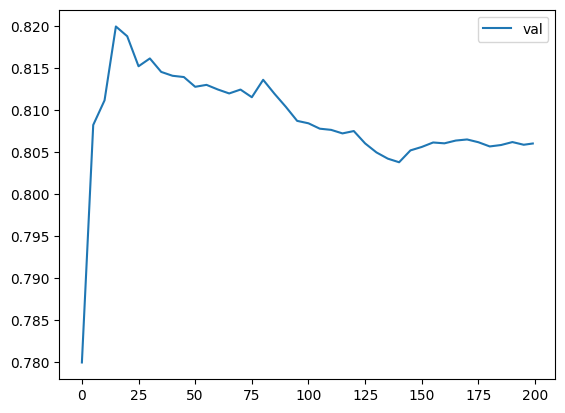

In [107]:
plt.plot(df_score.num_iter, df_score.val_auc, label = 'val')
plt.legend()

### XGBoost parameter tuning
### -> Tuning Eta
### --> Eta = 0.3

- Eta, also known as the learning rate, determines the influence of the following model when correcting the results of the previous model. If the weight is set to 1.0, all new predictions are used to correct the previous ones. However, when the weight is 0.3, only 30% of the new predictions are considered. In essence, eta governs the size of the steps taken during the learning process.

Now, let’s explore how different values of eta impact model performance. To facilitate this, we’ll create a dictionary called ‘scores‘ to store the performance scores for each value of eta.

In [108]:
scores = {}

In [109]:
%%capture output

xgb_params = {
    'eta' : 0.3,
    'max_depth' : 6,
    'min_child_weight' : 1,

    'objective' : 'binary:logistic',
    'eval_metric' : 'auc',

    'nthread' : 8,
    'seed' : 1,
    'verbosity' : 1
}

model = xgb.train(xgb_params, dtrain, num_boost_round = 200, verbose_eval = 5, evals = watchlist)

In [110]:
# We aim to structure keys in the format ‘eta=0.3’ to serve as identifiers in the scores dictionary
'eta=%s' % (xgb_params['eta'])

'eta=0.3'

In [111]:
# We once again employ the ‘parse_xgb_output‘ function, which we defined in the previous cell. 
# This function returns a dataframe that contains train_auc and val_auc values for different num_iter
key = 'eta=%s' % (xgb_params['eta'])
scores[key] = parse_xgb_output(output)
key

'eta=0.3'

In [112]:
# Now the dictionary scores contains the dataframe for this eta
scores

{'eta=0.3':     num_iter  train_auc  val_auc
 0          0    0.86653  0.77999
 1          5    0.92969  0.80822
 2         10    0.95512  0.81115
 3         15    0.96767  0.81993
 4         20    0.97648  0.81877
 5         25    0.98248  0.81520
 6         30    0.98844  0.81613
 7         35    0.99244  0.81453
 8         40    0.99393  0.81407
 9         45    0.99568  0.81392
 10        50    0.99723  0.81276
 11        55    0.99804  0.81299
 12        60    0.99861  0.81244
 13        65    0.99916  0.81197
 14        70    0.99962  0.81243
 15        75    0.99975  0.81152
 16        80    0.99989  0.81359
 17        85    0.99993  0.81193
 18        90    0.99998  0.81038
 19        95    0.99999  0.80871
 20       100    0.99999  0.80842
 21       105    1.00000  0.80778
 22       110    1.00000  0.80764
 23       115    1.00000  0.80722
 24       120    1.00000  0.80750
 25       125    1.00000  0.80603
 26       130    1.00000  0.80496
 27       135    1.00000  0.80422
 28

In [113]:
scores['eta=0.3']

,num_iter,train_auc,val_auc
0,0,0.86653,0.77999
1,5,0.92969,0.80822
2,10,0.95512,0.81115
3,15,0.96767,0.81993
4,20,0.97648,0.81877
5,25,0.98248,0.81520
6,30,0.98844,0.81613
7,35,0.99244,0.81453
8,40,0.99393,0.81407
9,45,0.99568,0.81392


### --> Eta = 1.0

In [114]:
# Capture wasn't working, so i used alternative capture instead
# Define the alternative capture function
import io
from contextlib import redirect_stdout

class Output:
    def __init__(self, text):
        self.stdout = text

In [115]:
# Now, let's see the eta value to it's maximum, which is 1.0
xgb_params = {
    'eta' : 1.0,
    'max_depth' : 6,
    'min_child_weight' : 1,

    'objective' : 'binary:logistic',
    'eval_metric' : 'auc',

    'nthread' : 8,
    'seed' : 1,
    'verbosity' : 1
}

# Capture output
f = io.StringIO()
with redirect_stdout (f):
    model = xgb.train(xgb_params, dtrain, num_boost_round = 200, verbose_eval = 5, evals = watchlist)

output = Output(f.getvalue())

# Parse and store immediately
key = 'eta=%s' % (xgb_params['eta'])
scores[key] = parse_xgb_output(output)

# Verify
print(key)
scores[key]

eta=1.0


,num_iter,train_auc,val_auc
0,0,0.86653,0.77999
1,5,0.96126,0.78834
2,10,0.98555,0.78862
3,15,0.99523,0.78400
4,20,0.99943,0.78606
5,25,0.99997,0.79065
6,30,1.00000,0.78718
7,35,1.00000,0.78548
8,40,1.00000,0.78776
9,45,1.00000,0.78904


### --> Eta = 0.1

In [116]:
# Now, let's see the eta value to it's maximum, which is 0.1
xgb_params = {
    'eta' : 0.1,
    'max_depth' : 6,
    'min_child_weight' : 1,

    'objective' : 'binary:logistic',
    'eval_metric' : 'auc',

    'nthread' : 8,
    'seed' : 1,
    'verbosity' : 1
}

# Capture output
f = io.StringIO()
with redirect_stdout (f):
    model = xgb.train(xgb_params, dtrain, num_boost_round = 200, verbose_eval = 5, evals = watchlist)

output = Output(f.getvalue())

# Parse and store immediately
key = 'eta=%s' % (xgb_params['eta'])
scores[key] = parse_xgb_output(output)

# Verify
print(key)
scores[key]

eta=0.1


,num_iter,train_auc,val_auc
0,0,0.86653,0.77999
1,5,0.90462,0.79276
2,10,0.91936,0.80573
3,15,0.93128,0.81241
4,20,0.94007,0.81551
5,25,0.94698,0.81664
6,30,0.95175,0.81942
7,35,0.95668,0.82229
8,40,0.96125,0.82243
9,45,0.96437,0.82507


### --> Eta = 0.05

In [117]:
# Now, let's see the eta value to it's maximum, which is 0.05
xgb_params = {
    'eta' : 0.05,
    'max_depth' : 6,
    'min_child_weight' : 1,

    'objective' : 'binary:logistic',
    'eval_metric' : 'auc',

    'nthread' : 8,
    'seed' : 1,
    'verbosity' : 1
}

# Capture output
f = io.StringIO()
with redirect_stdout (f):
    model = xgb.train(xgb_params, dtrain, num_boost_round = 200, verbose_eval = 5, evals = watchlist)

output = Output(f.getvalue())

# Parse and store immediately
key = 'eta=%s' % (xgb_params['eta'])
scores[key] = parse_xgb_output(output)

# Verify
print(key)
scores[key]

eta=0.05


,num_iter,train_auc,val_auc
0,0,0.86653,0.77999
1,5,0.88634,0.79497
2,10,0.90122,0.79380
3,15,0.90940,0.80111
4,20,0.91725,0.80696
5,25,0.92357,0.80785
6,30,0.92911,0.80999
7,35,0.93427,0.81284
8,40,0.93912,0.81369
9,45,0.94399,0.81552


### --> Eta = 0.01

In [118]:
# Now, let's assess the performance for 'Eta = 0.01'
xgb_params = {
    'eta' : 0.01,
    'max_depth' : 6,
    'min_child_weight' : 1,

    'objective' : 'binary:logistic',
    'eval_metric' : 'auc',

    'nthread' : 8,
    'seed' : 1,
    'verbosity' : 1
}

# Capture output
f = io.StringIO()
with redirect_stdout (f):
    model = xgb.train(xgb_params, dtrain, num_boost_round = 200, verbose_eval = 5, evals = watchlist)

output = Output(f.getvalue())

# Parse and store immediately
key = 'eta=%s' % (xgb_params['eta'])
scores[key] = parse_xgb_output(output)

# Verify
print(key)
scores[key]

eta=0.01


,num_iter,train_auc,val_auc
0,0,0.86653,0.77999
1,5,0.87039,0.77827
2,10,0.87211,0.77828
3,15,0.87412,0.78300
4,20,0.87621,0.78749
5,25,0.88611,0.79587
6,30,0.89308,0.79968
7,35,0.89641,0.79983
8,40,0.89874,0.79885
9,45,0.90041,0.79691


### Plotting Eta

In [119]:
# Now that we’ve inserted key-value pairs and gathered information from different runs, we can examine the keys in the dictionary. 
# Next we can compare all runs of ‘eta=0.3’, ‘eta=1.0’, ‘eta=0.1’, ‘eta=0.05’, and ‘eta=0.01’
scores.keys()

dict_keys(['eta=0.3', 'eta=1.0', 'eta=0.1', 'eta=0.05', 'eta=0.01'])

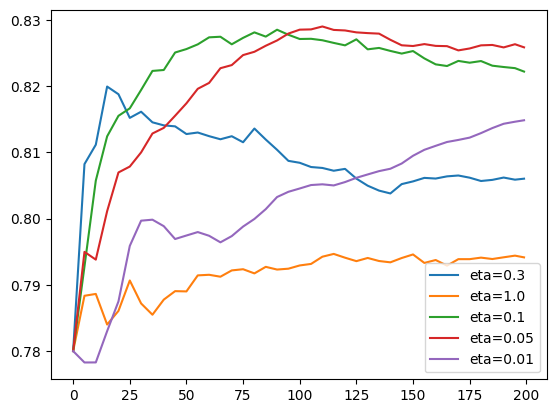

In [120]:
# Let's plot the information of our runs
for key, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=key)
plt.legend()

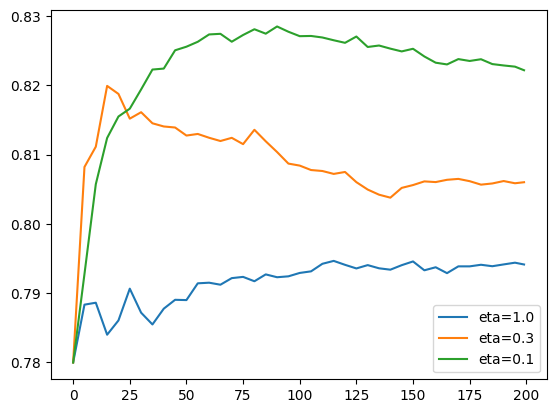

In [121]:
# Let's concentrate on a few graphs for all initial amalysis.
# We will plot three of them: 'eta=1.0', 'eta=0.3' and 'eta=0.1'
etas = ['eta=1.0', 'eta=0.3', 'eta=0.1']
for eta in etas:
    df_score = scores[eta]
    plt.plot(df_score.num_iter, df_score.val_auc, label=eta)
plt.legend()

- This plot provides a clearer view of the results. Notably, ‘eta=1.0’ exhibits the worst performance. It quickly reaches peak performance but then experiences a sharp decline, maintaining a consistently poor level. ‘eta=0.3’ performs reasonably well until around iteration 25, after which it steadily deteriorates. On the other hand, ‘eta=0.1’ demonstrates a slower growth rate, reaching its peak at a later stage before descending. This pattern is a direct reflection of the learning rate’s influence.

- The learning rate controls both the speed at which the model learns and the size of the steps it takes during each iteration. If the steps are too large, the model learns rapidly but eventually starts to degrade due to the excessive step size, resulting in overfitting. Conversely, a smaller learning rate signifies slower but more stable learning. Such models tend to degrade more gradually, and their overfitting tendencies are less pronounced compared to models with higher learning rates.

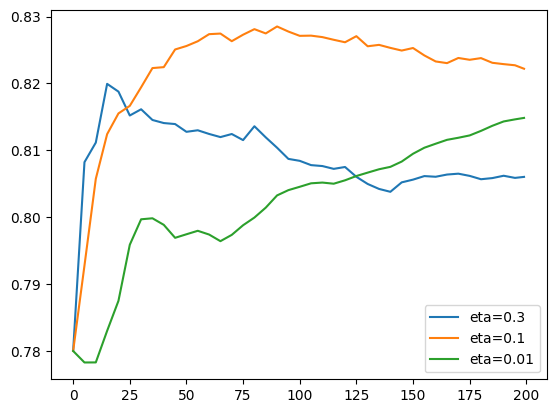

In [122]:
# Next let’s look at eta=0.3, eta=0.1, and eta=0.01
etas = ['eta=0.3', 'eta=0.1', 'eta=0.01']
for eta in etas:
    df_score = scores[eta]
    plt.plot(df_score.num_iter, df_score.val_auc, label=eta)
plt.legend()

- ‘eta=0.01’ displays an extremely slow learning rate, making it challenging to estimate how long it might take to outperform the other model (represented by the orange curve). This model’s progress is painstakingly slow, as the steps it takes are exceedingly tiny.

- On the other hand, ‘eta=0.3’ takes a few significant steps initially but succumbs to overfitting more rapidly. In this plot, ‘eta=0.1’ seems to strike the ideal balance, particularly between 50 and 75 iterations. It may take a bit longer to reach its peak performance, but the resulting performance improvement justifies the wait.

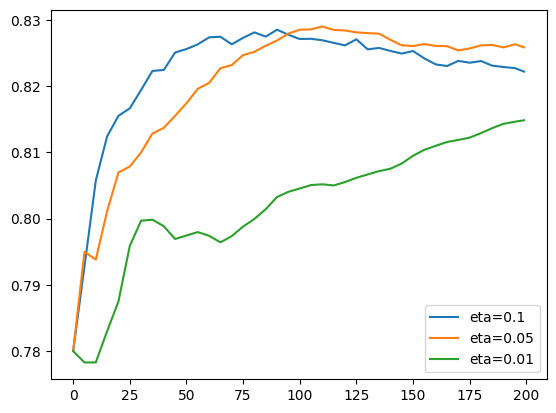

In [123]:
# There was also eta=0.05 let’s finally look also at this plot
etas = ['eta=0.1', 'eta=0.05', 'eta=0.01']
for eta in etas:
    df_score = scores[eta]
    plt.plot(df_score.num_iter, df_score.val_auc, label=eta)
plt.legend()

- The ‘eta=0.05’ model requires approximately twice as many iterations to converge when compared to the blue model (‘eta=0.1’). Although it takes smaller steps and requires more time, the end result is still inferior to the blue model. Thus, it’s evident that the ‘eta=0.1’ model stands out as the best option, as it achieves better performance with fewer steps.

- Now that we’ve found the best value for ‘eta,’ in the second part of XGBoost parameter tuning, we’ll focus on tuning two more parameters: ‘max_depth‘ and ‘min_child_weight‘ before proceeding to train the final model.

### Tuning max_depth

### --> Max_depth = 6

Now that we’ve set ‘eta‘ to 0.1, which we determined to be the best value, we’re going to focus on tuning the ‘max_depth‘ parameter. To do that, we’ll reset our scores dictionary to keep track of the new experiments. Initially, we’ll train a model with the same parameters as before, using it as a baseline for comparing different ‘max_depth‘ values.

In [124]:
scores = {}

In [125]:
%%capture output

xgb_params = {
    'eta' : 0.1,
    'max_depth' : 6,
    'min_child_weight' : 1,

    'objective' : 'binary:logistic',
    'eval_metric' : 'auc',

    'nthread' : 8,
    'seed' : 1,
    'verbosity' : 1
}

model = xgb.train(xgb_params, dtrain, num_boost_round = 200, verbose_eval = 5, evals = watchlist)

In [126]:
key = 'max_depth=%s' % (xgb_params['max_depth'])
scores[key] = parse_xgb_output(output)
key

'max_depth=6'

### --> Max_depth = 3

In [127]:
# Let’s set the ‘max_depth‘ value to 3
xgb_params = {
    'eta' : 0.1,
    'max_depth' : 3,
    'min_child_weight' : 1,

    'objective' : 'binary:logistic',
    'eval_metric' : 'auc',

    'nthread' : 8,
    'seed' : 1,
    'verbosity' : 1
}

# Capture output
f = io.StringIO()
with redirect_stdout(f):
    model = xgb.train(xgb_params, dtrain, num_boost_round = 200, verbose_eval = 5, evals = watchlist)

output = Output(f.getvalue())

# Parse and store immediately
key = 'max_depth=%s' % (xgb_params['max_depth'])
scores[key] = parse_xgb_output(output)

# Verify
print(key)

max_depth=3


### --> Max_depth = 4

In [128]:
# Let’s go through the process once more for ‘max_depth=4‘
xgb_params = {
    'eta' : 0.1,
    'max_depth' : 4,
    'min_child_weight' : 1,

    'objective' : 'binary:logistic',
    'eval_metric' : 'auc',

    'nthread' : 8,
    'seed' : 1,
    'verbosity' : 1
}

# Capture output
f = io.StringIO()
with redirect_stdout (f):
    model = xgb.train(xgb_params, dtrain, num_boost_round = 200, verbose_eval = 5, evals = watchlist)

output = Output(f.getvalue())

# Parse and store immediately
key = 'max_depth=%s' % (xgb_params['max_depth'])
scores[key] = parse_xgb_output(output)

# Verify
print(key)

max_depth=4


### --> Max_depth = 10

In [129]:
# Let’s go through the process once more for ‘max_depth=10‘
xgb_params = {
    'eta' : 0.1,
    'max_depth' : 10,
    'min_child_weight' : 1,

    'objective' : 'binary:logistic',
    'eval_metric' : 'auc',

    'nthread' : 8,
    'seed' : 1,
    'verbosity' : 1
}

# Capture output
f = io.StringIO()
with redirect_stdout (f):
    model = xgb.train(xgb_params, dtrain, num_boost_round = 200, verbose_eval = 5, evals = watchlist)

output = Output(f.getvalue())

# Parse and store immediately
key = 'max_depth=%s' % (xgb_params['max_depth'])
scores[key] = parse_xgb_output(output)

# Verify
print(key)

max_depth=10


### Plotting max_depth

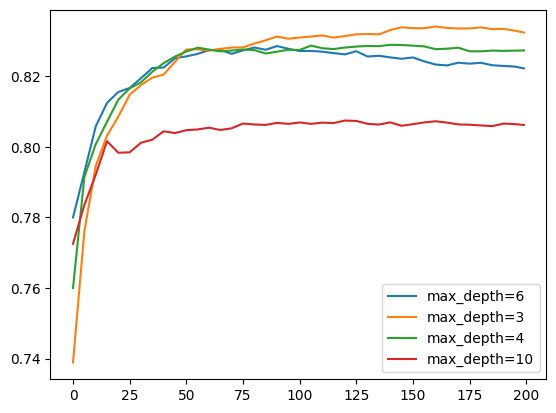

In [130]:
# Now that we’ve collected data from four runs, let’s plot this information and determine which model performs the best
for max_depth, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=max_depth)

plt.legend()

- We see the depth of 10 is the worst.

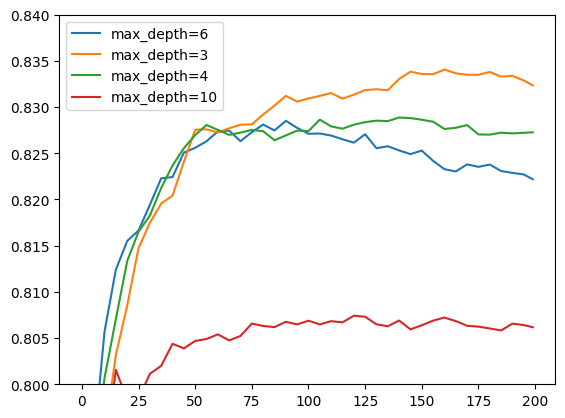

In [131]:
# To get a better view on the y-area between 0.8 and 0.84 we can limit the plot as shown in the next snippet
for max_depth, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=max_depth)

plt.ylim(0.8, 0.84)
plt.legend()

- 'max_depth = 6' is the second worst. We conclude the 'max_depth = 3' is the best depth for us.

### Tuning min_child_weight

### --> min_child_weight = 1

Now, we’ll set ‘eta‘ to 0.1 and ‘max_depth‘ to 3. We’re ready to start tuning the last parameter, which is ‘min_child_weight.’ To do this, we need to reset our scores dictionary once again to track the new experiments. Initially, we’ll train a model with the same parameters as before, but we’ll set ‘min_child_weight‘ to 1. This model will serve as our baseline for comparing different ‘min_child_weight‘ values.

In [132]:
scores = {}

In [133]:
%%capture output

xgb_params = {
    'eta' : 0.1,
    'max_depth' : 3,
    'min_child_weight' : 1,

    'objective' : 'binary:logistic',
    'eval_metric' : 'auc',

    'nthread' : 8,
    'seed' : 1,
    'verbosity' : 1
}

model = xgb.train(xgb_params, dtrain, num_boost_round = 200, verbose_eval = 5, evals = watchlist)

In [134]:
key = 'min_child_weight=%s' % (xgb_params['min_child_weight'])
scores[key] = parse_xgb_output(output)
key

'min_child_weight=1'

### --> min_child_weight = 10

In [135]:
# Let’s set the ‘min_child_weight‘ value to 10
xgb_params = {
    'eta' : 0.1,
    'max_depth' : 3,
    'min_child_weight' : 10,

    'objective' : 'binary:logistic',
    'eval_metric' : 'auc',

    'nthread' : 8,
    'seed' : 1,
    'verbosity' : 1
}

# Capture output
f = io.StringIO()
with redirect_stdout (f):
    model = xgb.train(xgb_params, dtrain, num_boost_round = 200, verbose_eval = 5, evals = watchlist)

output = Output(f.getvalue())

# Parse and store immediately
key = 'min_child_weight=%s' % (xgb_params['min_child_weight'])
scores[key] = parse_xgb_output(output)

# Verify
print(key)

min_child_weight=10


### --> min_child_weight = 30

In [136]:
# Let’s set the ‘min_child_weight‘ value to 30
xgb_params = {
    'eta' : 0.1,
    'max_depth' : 3,
    'min_child_weight' : 30,

    'objective' : 'binary:logistic',
    'eval_metric' : 'auc',

    'nthread' : 8,
    'seed' : 1,
    'verbosity' : 1
}

# Capture output
f = io.StringIO()
with redirect_stdout (f):
    model = xgb.train(xgb_params, dtrain, num_boost_round = 200, verbose_eval = 5, evals = watchlist)

output = Output(f.getvalue())

# Parse and store immediately
key = 'min_child_weight=%s' % (xgb_params['min_child_weight'])
scores[key] = parse_xgb_output(output)

# Verify
print(key)

min_child_weight=30


### Plotting min_child_weight

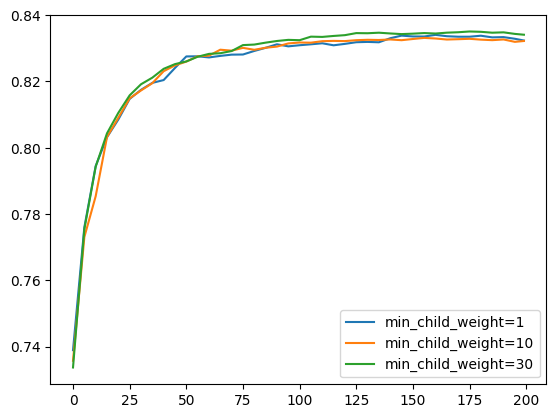

In [137]:
# This should give us an idea if we actually need to increase this value or not
# Now we can compare all runs of ‘min_child_weight=1‘, ‘min_child_weight=10‘, and ‘min_child_weight=30‘
for min_child_weight, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=min_child_weight)

plt.legend()

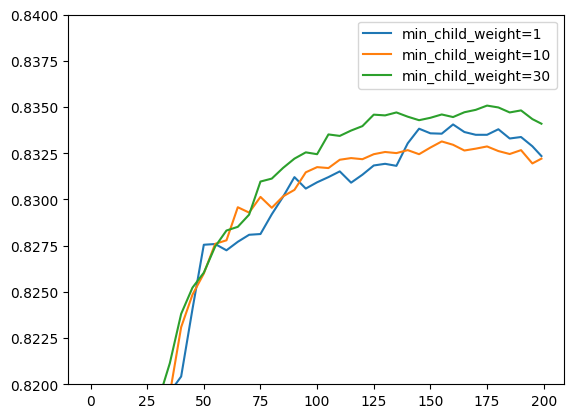

In [138]:
# Here it’s not so easy to see which one is the best. We should also enlarge it a bit.
for min_child_weight, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=min_child_weight)

plt.ylim(0.82, 0.84)
plt.legend()

- In this plot, a ‘min_child_weight‘ of 30 appears to be the best-performing value. I’ve opted to select a ‘min_child_weight‘ of 1. It’s worth noting that parameter tuning can be influenced by various factors, and flexibility in choosing the optimal values is important.

### Train final model

In [139]:
xgb_params = {
    'eta' : 0.1,
    'max_depth' : 3,
    'min_child_weight' : 1,

    'objective' : 'binary:logistic',
    'eval_metric' : 'auc',

    'nthread' : 8,
    'seed' : 1,
    'verbosity' : 1
}

model = xgb.train(xgb_params, dtrain, num_boost_round = 175)

In [140]:
xgb_params = {
    'eta' : 0.1,
    'max_depth' : 3,
    'min_child_weight' : 30,

    'objective' : 'binary:logistic',
    'eval_metric' : 'auc',

    'nthread' : 8,
    'seed' : 1,
    'verbosity' : 1
}

model = xgb.train(xgb_params, dtrain, num_boost_round = 175)

### Selecting the final model

This is the final part of the module ‘Decision Trees and Ensemble Learning – Part 14.’ This time, we revisit the best model of each type and evaluate their performance on the validation data. Based on these evaluations, we will select the overall best model and train it on the full training dataset. The final model will then be evaluated on the test set.

### Choosing between XGBoost, random forest and decision tree

#### Retain the best model of each type

In [141]:
# Let's retain the best Decision Tree model we had
dt = DecisionTreeClassifier(max_depth = 6, min_samples_leaf = 15)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [142]:
# Let's retain the best Random Forest model we had
rf = RandomForestClassifier(n_estimators = 200,
                            max_depth = 10,
                            min_samples_leaf = 3,
                            random_state = 1)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [143]:
# Let's retain the best XGBoost model we had
xgb_params = {
    'eta' : 0.1,
    'max_depth' : 3,
    'min_child_weight' : 1,

    'objective' : 'binary:logistic',
    'eval_metric' : 'auc',

    'nthread' : 8,
    'seed' : 1,
    'verbosity' : 1
}

model = xgb.train(xgb_params, dtrain, num_boost_round = 175)

### Evaluating all the best of models on validation data

In [144]:
# Decision Tree
y_pred = dt.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.7850802838390931

In [145]:
# Random Forest
y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.8246258264512848

In [146]:
# XGBoost Model
y_pred = model.predict(dval)
roc_auc_score(y_val, y_pred)

0.8334715797631446

- We see that the XGBoost model has the best auc score. We’ll use this to train the final model.

### Training the final model

To train the final model, we will use the entire dataset. Following the training, we will evaluate the final model on our test dataset.

In [147]:
df_full_train

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
3668,ok,22,owner,48,48,married,no,fixed,60,110.0,3000.0,0.0,1000,1460
2540,default,8,other,60,41,married,no,freelance,45,62.0,0.0,0.0,1800,2101
279,ok,2,parents,36,19,married,no,fixed,35,162.0,4000.0,100.0,400,570
3536,ok,1,owner,12,61,married,no,others,45,103.0,20000.0,0.0,300,650
3866,ok,13,owner,60,27,married,no,fixed,35,253.0,7000.0,0.0,1060,1750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
332,default,4,owner,60,47,married,no,freelance,75,0.0,13500.0,0.0,1900,1976
1293,ok,2,rent,60,28,single,no,fixed,45,101.0,0.0,0.0,1300,1333
4023,ok,2,parents,36,25,single,no,fixed,35,110.0,0.0,0.0,500,1200
3775,ok,4,other,60,25,single,no,fixed,35,162.0,0.0,0.0,1800,2999


In [148]:
# Reset the index
df_full_train = df_full_train.reset_index(drop=True)

In [149]:
# The next steps involve setting the ‘y’ value and removing the ‘status’ column from the training dataframe to prevent accidental use of this column during training
y_full_train = (df_full_train.status == 'default').astype(int).values
y_full_train

array([0, 1, 0, ..., 0, 0, 1], shape=(3563,))

In [150]:
del df_full_train['status']

-> We can create dictionaries for the DictVectorizer and then use the fit_transform method to obtain X_full_train. For X_test, we only need to call the transform method since the vectorizer has already been fitted.

In [152]:
dicts_full_train = df_full_train.to_dict(orient = 'records')

dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

dicts_test = df_test.to_dict(orient = 'records')
X_test = dv.transform(dicts_test)

-> Inspecting the ‘feature_names’ reveals the one-hot-encoded columns and confirms that there is no ‘status’ column, indicating that our data preparation is complete and we are ready to train the final model.

In [153]:
feature_names = list(dv.get_feature_names_out())
feature_names

['age',
 'amount',
 'assets',
 'debt',
 'expenses',
 'home=ignore',
 'home=other',
 'home=owner',
 'home=parents',
 'home=private',
 'home=rent',
 'home=unk',
 'income',
 'job=fixed',
 'job=freelance',
 'job=others',
 'job=partime',
 'job=unk',
 'marital=divorced',
 'marital=married',
 'marital=separated',
 'marital=single',
 'marital=unk',
 'marital=widow',
 'price',
 'records=no',
 'records=yes',
 'seniority',
 'time']

-> XGBoost models require data in the form of DMatrix for training. We also prepare the test data, which doesn’t require labels, as we’ll evaluate it using Scikit-Learn.

In [155]:
feature_names = list(dv.get_feature_names_out())
dfulltrain = xgb.DMatrix(X_full_train, label=y_full_train, feature_names=feature_names)

dtest = xgb.DMatrix(X_test, feature_names=feature_names)

In [156]:
# Let's set the parameters and train the final model
xgb_params = {
    'eta' : 0.1,
    'max_depth' : 3,
    'min_child_weight' : 1,

    'objective' : 'binary:logistic',
    'eval_metric' : 'auc',

    'nthread' : 8,
    'seed' : 1,
    'verbosity' : 1
}

model = xgb.train(xgb_params, dfulltrain, num_boost_round = 175)

In [157]:
# Evaluating the final model
y_pred = model.predict(dtest)
roc_auc_score(y_test, y_pred)

0.8299814280826938

--> The performance of the final model is a little bit worse than the best XGBoost model (0.831), but it’s only like a fraction of one percent. So this is fine. We can conclude that our model didn’t overfit. The final model generalizes quite well on unseen data. XGBoost models are often one of the best models at least for tabular data (dataframe with features). The downside of this is that XGBoost models are more complex, it’s more difficult to tune, it has more parameters, and it’s easier to overfit with XGBoost. But you can get a better performance out of this.